<a href="https://colab.research.google.com/github/jeremiahoclark/open_source_colabs/blob/main/Wan2_1_AI_Animation_HandsOn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Enhanced AI Animation Hands‑On: Wan 2.1 (1.3B) — College‑Style Lab

Welcome! In this textbook‑style lab, you'll learn **AI animation** using **Wan 2.1**, focusing on the **1.3B Text‑to‑Video** model for **free Google Colab (T4)** compatibility.

**Learning outcomes**
- Explain, at a high level, how **Diffusion Transformers (DiT)** synthesize videos.
- Configure a Colab runtime and install dependencies for **Wan 2.1** via **Diffusers**.
- Generate a **5‑second 480p** video from text with adjustable parameters.
- Practice **prompt engineering** for motion quality and style control.
- Diagnose common runtime issues (VRAM, CUDA, dependency conflicts) safely and ethically.

**Agenda**
1) Theory Primer (with mini visualization)  
2) Environment & GPU Check  
3) Install Dependencies (torch / diffusers)  
4) Download or load Wan 2.1 (1.3B) via Diffusers  
5) **T2V Generation lab with sliders**  
6) Prompt Engineering Lab + Batch variations  
7) I2V Stretch Goal (notes + template)  
8) Troubleshooting & Ethics + Quiz



## 1) Theory Primer — Diffusion Transformers in 90 seconds
Diffusion adds noise to data and **denoises** it step‑by‑step back into structure. **Transformers** provide long‑range dependencies across **space (pixels)** and **time (frames)**, enabling coherent motion.

> Reflection: Why might more denoising steps improve detail but cost time?


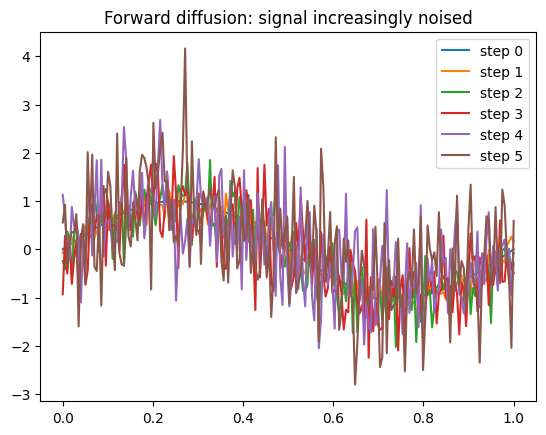

Reverse diffusion: a learned denoiser removes noise over steps to recover structure (and motion across frames).


In [1]:

# Mini "forward diffusion" visualization (noise addition)
# (matplotlib only, single plot, no color styles)
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
steps = 6
xs = np.linspace(0, 1, 200)
fig, ax = plt.subplots()
for t in range(steps):
    noise = np.random.normal(scale=t/(steps-1+1e-9), size=xs.shape)
    ys = np.sin(2*np.pi*xs) + noise
    ax.plot(xs, ys, label=f'step {t}')
ax.set_title('Forward diffusion: signal increasingly noised')
ax.legend()
plt.show()

print("Reverse diffusion: a learned denoiser removes noise over steps to recover structure (and motion across frames).")



## 2) Environment & GPU Check
Run this to confirm you have a GPU (T4 or better). If `None`, switch Colab to **Runtime → Change runtime type → T4 GPU**.


In [2]:

import subprocess

try:
    gpu_info = subprocess.check_output('nvidia-smi', shell=True, text=True)
    print(gpu_info)
except Exception as e:
    print("GPU not found. In Colab, go to Runtime → Change runtime type → select GPU (T4).")


Thu Sep 25 19:12:36 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----


## 3) Install Dependencies
Installs PyTorch (CUDA), Diffusers, Transformers, and utilities. Re‑run after a fresh runtime.


In [3]:
# If running in Colab, these will install to the current environment.
# Torch wheels are selected by pip automatically in Colab.
!pip -q install --upgrade pip
!pip -q install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu121
!pip -q install --upgrade diffusers transformers accelerate sentencepiece safetensors einops
!pip -q install  opencv-python pillow matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.9 MB/s eta 0:00:00



## 4) Load Wan 2.1 (1.3B) with Diffusers
This section uses Diffusers’ official Wan pipelines. The **1.3B T2V** variant targets **480p** to fit free T4 VRAM constraints.


In [ ]:

from diffusers import AutoencoderKLWan, WanPipeline
from diffusers.utils import export_to_video
from diffusers.schedulers.scheduling_unipc_multistep import UniPCMultistepScheduler
import torch, time

# Choose a model id; 1.3B T2V is recommended for T4
T2V_MODEL = "Wan-AI/Wan2.1-T2V-1.3B-Diffusers"  # 480p target

# Load VAE & pipeline
vae = AutoencoderKLWan.from_pretrained(T2V_MODEL, subfolder="vae", torch_dtype=torch.float32)
scheduler = UniPCMultistepScheduler(
    prediction_type='flow_prediction',
    use_flow_sigmas=True,
    num_train_timesteps=1000,
    flow_shift=3.0  # 3.0 for 480p
)
pipe = WanPipeline.from_pretrained(T2V_MODEL, vae=vae, torch_dtype=torch.bfloat16)
pipe.scheduler = scheduler
device = "cuda" if torch.cuda.is_available() else "cpu"
pipe = pipe.to(device)

print("Loaded:", T2V_MODEL, "on", device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/508M [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/400 [00:00<?, ?B/s]

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

transformer/diffusion_pytorch_model-0000(…):   0%|          | 0.00/5.00G [00:00<?, ?B/s]

transformer/diffusion_pytorch_model-0000(…):   0%|          | 0.00/677M [00:00<?, ?B/s]

(…)ion_pytorch_model.safetensors.index.json: 0.00B [00:00, ?B/s]


## 5) **Lab A — Text‑to‑Video Generation (Interactive)**
Use the form fields to generate a 5‑second clip. Defaults are conservative for T4.


In [ ]:

#@title T2V Generation — Configure & Run
prompt = "A puppy chasing a butterfly in a meadow at golden hour, cinematic, smooth motion." #@param {type:"string"}
negative_prompt = "flicker, blurry, distorted faces, low quality, washed out, static frames" #@param {type:"string"}
height = 480 #@param {type:"integer"}
width = 832  #@param {type:"integer"}
num_frames = 81 #@param {type:"integer"}
guidance_scale = 5.0 #@param {type:"number"}

torch.cuda.empty_cache()
t0 = time.time()
out_frames = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    height=height, width=width,
    num_frames=num_frames,
    guidance_scale=guidance_scale
).frames[0]
mp4_path = "wan2_1_t2v_output.mp4"
export_to_video(out_frames, mp4_path, fps=16)
t1 = time.time()

print(f"Saved → {mp4_path} (generation time: {t1 - t0:.1f}s)")



## 6) Lab B — Prompt Engineering & Batch Variations
Tweak style and motion verbs. Then run a small batch to compare results.


In [ ]:

from itertools import product

base = "A {subject} moving through a {setting}, {style}, dynamic camera, detailed, natural motion."
subjects = ["cat", "robot", "paper plane"]
settings = ["forest clearing", "city rooftop", "beach at dusk"]
styles = ["cinematic", "anime", "abstract art"]

variants = []
for s in subjects:
    for g in settings:
        for st in styles:
            variants.append(base.format(subject=s, setting=g, style=st))

print("We will render a small subset to save time.")
subset = variants[:2]

for i, p in enumerate(subset, 1):
    print(f"[{i}/{len(subset)}] {p}")
    torch.cuda.empty_cache()
    frames = pipe(
        prompt=p,
        negative_prompt="flicker, blurry, low quality, static frames",
        height=480, width=832,
        num_frames=65,
        guidance_scale=5.0
    ).frames[0]
    export_to_video(frames, f"batch_{i:02d}.mp4", fps=16)

print("Batch complete. Inspect the videos and compare style/motion.")



## 7) Stretch Goal — Image‑to‑Video (I2V)
**Note:** Wan 2.1 I2V 14B yields the best quality but typically exceeds free T4 VRAM. If you have **Colab Pro/A100**, you can try it. The code below (commented) loads the I2V pipeline and resizes the input image to a valid area for 720p.


In [ ]:

# Uncomment to attempt on a high‑VRAM GPU (A100/Pro):
# from diffusers import AutoencoderKLWan, WanImageToVideoPipeline
# from transformers import CLIPVisionModel
# import numpy as np, torch
# from diffusers.utils import export_to_video, load_image
# device = "cuda" if torch.cuda.is_available() else "cpu"
#
# I2V_MODEL = "Wan-AI/Wan2.1-I2V-14B-720P-Diffusers"
# image_encoder = CLIPVisionModel.from_pretrained(I2V_MODEL, subfolder="image_encoder", torch_dtype=torch.float32)
# vae_i2v = AutoencoderKLWan.from_pretrained(I2V_MODEL, subfolder="vae", torch_dtype=torch.float32)
# pipe_i2v = WanImageToVideoPipeline.from_pretrained(I2V_MODEL, vae=vae_i2v, image_encoder=image_encoder, torch_dtype=torch.bfloat16).to(device)
#
# # Load an example image
# img = load_image("https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/astronaut.jpg")
# max_area = 1280 * 720
# aspect_ratio = img.height / img.width
# mod_value = pipe_i2v.vae_scale_factor_spatial * pipe_i2v.transformer.config.patch_size[1]
# height = round((max_area * aspect_ratio) ** 0.5) // mod_value * mod_value
# width = round((max_area / aspect_ratio) ** 0.5) // mod_value * mod_value
# img = img.resize((width, height))
#
# frames = pipe_i2v(
#     image=img,
#     prompt="An astronaut hatching from an egg, cinematic, ultra‑detailed.",
#     negative_prompt="overexposed, static, blurry details, artifacts",
#     height=height, width=width,
#     num_frames=81,
#     guidance_scale=5.0
# ).frames[0]
# export_to_video(frames, "i2v_output.mp4", fps=16)
# print("Saved i2v_output.mp4")



## 8) Troubleshooting & Ethics

**Frequent issues (quick fixes)**
- **CUDA OOM**: Reduce `num_frames` (e.g., 49), keep `height×width≈480p`, close other notebooks, restart runtime.
- **Slow / stuck**: Rerun installs, ensure GPU active, reduce batch variations.
- **Flicker**: Increase steps (if using a scheduler with steps), improve negative prompt, try guidance 4.5–6.0.

**Responsible use**
- Avoid impersonation, deceptive media, and rights violations.
- When animating photos of people, obtain permission; disclose AI usage where appropriate.



## 9) Quick Quiz (self‑check)
1) What role does the Transformer play inside Wan’s diffusion?  
2) Why does increasing `num_frames` stress VRAM/time?  
3) Which parameters most directly affect style adherence?  
4) Name two tactics to mitigate flicker.
